# Прогнозирование продаж кроссовок на WB

## Описание задачи

Задача является финальным проектом хакатона **'Ритм продаж'**

Проект посвящен прогнозированию продаж всей обуви в категории кроссовок на Wildberries на окно в 2 недели. Бизнес задача состоит в получении прогноза для оперативного пополнения складских остатков, планирования спроса на продукт и проведения маркетинговых акций

Изначально даны 2 паркет-файлов с разделением данных по на тренировочную и тестовую выборки. Тестовые данные представленны данными по независимым переменным за 2 недели. Тренировочные данные включают в себя фичи и таргет за промежуток более, чем на полтора года.

Главная особенность данных состоит в двух вещах:

1. В трейне значения целевого признака кратны 3 (0, 3, 6, 9, ...)
2. В тренировочной выборке более 80% значений целевого признака - нули

В ходе работы над проектом тестировались разные гипотезы и архитектуры, в частности были опробованы LSTM, ансамблевые модели (сначала предсказываем нули классификацией, а все остальные добиваем регрессией), авторегрессионные модели (последовательное предсказание таргета день за днём через бустинг) с разными комбинациями параметров моделей. В частности, использовались разные метрики качества (обычная mae, взвешенная wmae и др.), функции ошибок (l1loss, huberloss и т.д.), параметры моделей с различным признаковым пространством, а также различными периодами тренировочной выборки (наиболее выигрышный - последний месяц перед тестом). Текущее решение - lgbm с признаковым пространством, включающим в себя, помимо скользящих, календарных и лаговых, эконометрические показатели (большой прирост, в частности, дали методы Кростона и Виллемейна)

Лушчее решение хакатона - рекуррентная нейросеть

### Структура ноутбука

1. **Конфигурация и утилиты** – импорт библиотек, настройка директорий, определение метрик
2. **Загрузка и предварительный осмотр данных** – отдельные маленькие ячейки показывают размеры, типы, пропуски, дубликаты, распределения.
3. **Сезонный бейзлайн** – константный прогноз таргета по среднесезонным признакам
4. **Модульная генерация признаков** – производится через класс TSFeatures. Вынесен в tools/cells. Создан, чтобы упростить работу с признаковып пространством
5. **Оценка моделей и обучение** – Построение ML-пайплайна и вывод решения

In [1]:
# Базовая настройка окружения и общие функции

import os
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go

# sklearn и модели
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import ParameterGrid
from sklearn.cluster import MiniBatchKMeans
from sklearn.decomposition import PCA

from lightgbm import LGBMRegressor

# статистика признаков
import phik
from phik.report import plot_correlation_matrix

# импорт генератора признаков
from tools.cells.tsfeatures import TSFeatures

warnings.filterwarnings('ignore')

# Путь к каталогу с данными. По умолчанию — ./data
# Чтобы переопределить, установите переменную окружения DATA_DIR.
DATA_DIR = Path(os.getenv('DATA_DIR', 'data')).resolve()
DATA_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42



def load_parquet(filename: str) -> pd.DataFrame:
    '''Загружает паркет-файл из DATA_DIR.'''
    path = DATA_DIR / filename
    if not path.exists():
        raise FileNotFoundError(f'Файл {path} не найден')
    return pd.read_parquet(path)


def load_csv(filename: str) -> pd.DataFrame:
    '''Загружает csv-файл из DATA_DIR.'''
    path = DATA_DIR / filename
    if not path.exists():
        raise FileNotFoundError(f'Файл {path} не найден')
    return pd.read_csv(path)


def load_all_raw():
    '''Загружает train/test/sub из DATA_DIR и возвращает кортеж.
    Используйте эту функцию везде, чтобы не дублировать чтение данных.
    '''
    train = load_parquet('train.parquet')
    test = load_parquet('test.parquet')
    sub = load_csv('sample_submission.csv')
    return train, test, sub

# Метрики качества модели
def mae(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.mean(np.abs(y_true - y_pred)))


def wmae(y_true, y_pred, w_pos=7.0):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    w = np.where(y_true > 0, w_pos, 1.0)
    return float(np.sum(w * np.abs(y_true - y_pred)) / np.sum(w))


def smape(y_true, y_pred, eps=1e-9):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.maximum(np.abs(y_true) + np.abs(y_pred), eps)
    return float(2.0 * np.mean(np.abs(y_pred - y_true) / denom))

# Настройки отображения pandas
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 140)


In [2]:
# Загрузка данных с помощью единой утилиты `load_all_raw()` (чтобы не читать файлы несколько раз)
train, test, sub = load_all_raw()

print('train:', train.shape)
print('test:', test.shape)
print('sub:', sub.shape)
print('\ntrain columns:', list(train.columns))
print('test columns:', list(test.columns))
print('sub columns:', list(sub.columns))


train: (309648, 6)
test: (12856, 5)
sub: (12856, 3)

train columns: ['nm_id', 'dt', 'qty', 'price', 'is_promo', 'prev_leftovers']
test columns: ['nm_id', 'dt', 'price', 'is_promo', 'prev_leftovers']
sub columns: ['nm_id', 'dt', 'qty']


In [4]:
print('date range')
print('train:', train['dt'].min(), '->', train['dt'].max())
print('test:', test['dt'].min(), '->', test['dt'].max())
print('sub:', sub['dt'].min(), '->', sub['dt'].max())

date range
train: 2024-07-04 00:00:00 -> 2025-07-07 00:00:00
test: 2025-07-08 00:00:00 -> 2025-07-21 00:00:00
sub: 2025-07-08 -> 2025-07-21


In [5]:
# приводим dt к datetime
for df_name, df in [('train', train), ('test', test), ('sub', sub)]:
    if 'dt' in df.columns:
        df['dt'] = pd.to_datetime(df['dt'])
    else:
        raise ValueError(f'В {df_name} нет колонки dt')

In [6]:
print('dtypes(train)')
print(train.dtypes)

dtypes(train)
nm_id                        str
dt                datetime64[ns]
qty                        int64
price                      int64
is_promo                   int64
prev_leftovers             int64
dtype: object


In [7]:
print('missing(train) top')
print(train.isna().mean().sort_values(ascending=False).head(20))

missing(train) top
nm_id             0.0
dt                0.0
qty               0.0
price             0.0
is_promo          0.0
prev_leftovers    0.0
dtype: float64


In [8]:
# проверяем дубликаты
if {'nm_id', 'dt', 'qty'}.issubset(train.columns):
    dup_cnt = train.duplicated(['nm_id', 'dt']).sum()
    print(f'Duplicates by (nm_id, dt): {dup_cnt}')

Duplicates by (nm_id, dt): 0


In [9]:
print('cardinalities')
print('nm_id unique train:', train['nm_id'].nunique())
print('nm_id unique test:', test['nm_id'].nunique() if 'nm_id' in test.columns else 'no nm_id column')
print('nm_id unique sub:', sub['nm_id'].nunique())

cardinalities
nm_id unique train: 2743
nm_id unique test: 949
nm_id unique sub: 949


In [10]:
# sparsity / zeros
zero_share = (train['qty'] == 0).mean()
print('zero share (train):', round(float(zero_share), 4))
print('qty summary:\n', train['qty'].describe(percentiles=[.5, .75, .9, .95, .99]))

zero share (train): 0.8708
qty summary:
 count    309648.000000
mean          0.845906
std           4.888326
min           0.000000
50%           0.000000
75%           0.000000
90%           3.000000
95%           3.000000
99%          12.000000
max         294.000000
Name: qty, dtype: float64


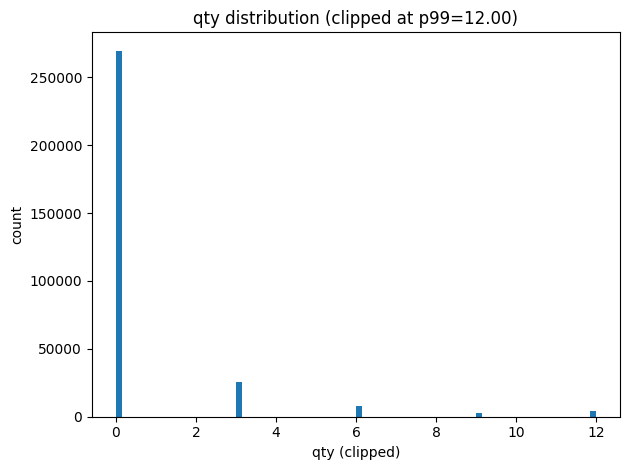

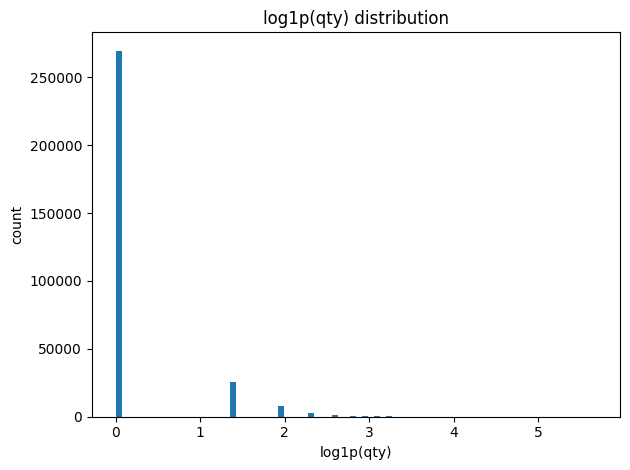

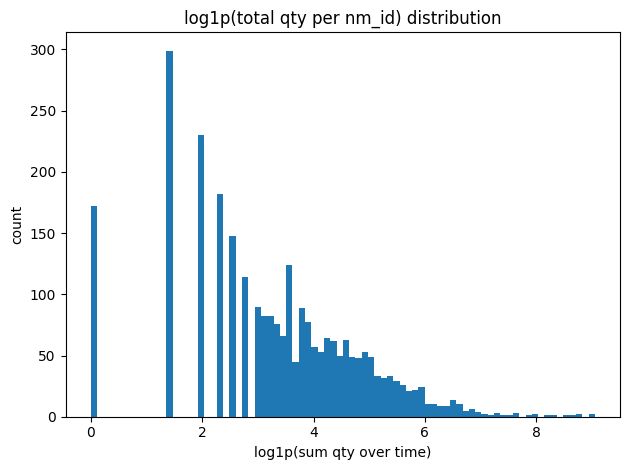

In [11]:
# Histogram of qty
y = train['qty'].astype(float).to_numpy()
p99 = np.quantile(y, 0.99) if len(y) else 0
cap = max(10, p99)
y_cap = np.clip(y, 0, cap)

plt.figure()
plt.hist(y_cap, bins=80)
plt.title(f'qty distribution (clipped at p99={p99:.2f})')
plt.xlabel('qty (clipped)')
plt.ylabel('count')
plt.tight_layout()
plt.show()

# Histogram of log1p(qty)
plt.figure()
plt.hist(np.log1p(y), bins=80)
plt.title('log1p(qty) distribution')
plt.xlabel('log1p(qty)')
plt.ylabel('count')
plt.tight_layout()
plt.show()

# Distribution of total sales per nm_id (sum over time)
nm_tot = train.groupby('nm_id')['qty'].sum().astype(float)
plt.figure()
plt.hist(np.log1p(nm_tot.to_numpy()), bins=80)
plt.title('log1p(total qty per nm_id) distribution')
plt.xlabel('log1p(sum qty over time)')
plt.ylabel('count')
plt.tight_layout()
plt.show()

**Что видно?**

1. **Сильная нулевая инфляция**

   Большая часть наблюдений по `qty` равна нулю. Простая модель, часто выдающая 0, даст неплохую MAE, но по взвешенной wMAE (вес 7 для положительных продаж) она будет слабее — ошибки на днях с реальными продажами будут чувствительными.

2. **Дискретные шипы**

   Положительные продажи выглядят как небольшие целые значения (например, 3, 6, 9, 12). Возможно, это связано с упаковкой/партией — стоит учесть округление до кратностей при постобработке прогнозов.

3. **По nm_id — тяжёлый хвост**

   По суммарным продажам по товарам видно, что большинство артикулов дают мало продаж, а небольшое число хитов даёт основную часть объёма. Это говорит в пользу моделей, учитывающих разные классы товаров по активности.


In [12]:
import plotly.graph_objects as go

fig = go.Figure()

rng = np.random.default_rng(42)
unique_ids = train['nm_id'].dropna().unique()
k = min(10, len(unique_ids))
random_ids = rng.choice(unique_ids, size=k, replace=False)

for nm in random_ids:
    df = train[train['nm_id'] == nm].sort_values('dt')

    # левая ось
    fig.add_trace(
        go.Scatter(
            x=df['dt'], y=df['qty'],
            mode='lines',
            name=f'qty {nm}',
            yaxis='y1',
        )
    )

    # правая ось
    fig.add_trace(
        go.Scatter(
            x=df['dt'], y=df['price'],
            mode='lines',
            name=f'price {nm}',
            yaxis='y2',
        )
    )

fig.update_layout(
    yaxis=dict(title='Количество (qty)'),
    yaxis2=dict(title='Цена (price)', overlaying='y', side='right'),
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='left', x=0),
    height=650,
)

fig.show()

In [13]:
# seasonal naive by day-of-week
# медиана qty по каждому (nm_id, dow) за последние window_days)

def fit_dow_median_baseline(train_df: pd.DataFrame, window_days: int = 56):
    '''
    Возвращает словари-lookup для прогнозов:
      - median qty per (nm_id, dow)
      - median qty per nm_id
      - global median
    Используем только последние window_days от конца train_df.
    '''
    df = train_df[['nm_id', 'dt', 'qty']].copy()
    df['dt'] = pd.to_datetime(df['dt'])
    max_dt = df['dt'].max()
    start_dt = max_dt - pd.Timedelta(days=window_days)

    df_w = df[df['dt'] >= start_dt].copy()
    df_w['dow'] = df_w['dt'].dt.dayofweek

    nm_dow_med = df_w.groupby(['nm_id', 'dow'])['qty'].median()
    nm_med = df_w.groupby('nm_id')['qty'].median()
    global_med = float(df_w['qty'].median())

    state = {
        'nm_dow_med': nm_dow_med,
        'nm_med': nm_med,
        'global_med': global_med,
        'max_dt': max_dt,
        'window_days': window_days,
    }
    return state


def predict_dow_median(df_future: pd.DataFrame, state) -> np.ndarray:
    '''
    df_future должен содержать: nm_id, dt
    '''
    fut = df_future[['nm_id', 'dt']].copy()
    fut['dt'] = pd.to_datetime(fut['dt'])
    fut['dow'] = fut['dt'].dt.dayofweek

    nm_dow_med = state['nm_dow_med']
    nm_med = state['nm_med']
    global_med = state['global_med']

    # map (nm_id, dow) -> median
    idx = pd.MultiIndex.from_frame(fut[['nm_id', 'dow']])
    pred = nm_dow_med.reindex(idx).to_numpy()

    # qty должен быть неотрицательный
    pred = np.clip(pred, 0, None)

    # обычно qty - целое
    pred = np.rint(pred).astype(int)
    return pred

In [14]:
max_dt = train['dt'].max()
val_days = 14
cutoff = max_dt - pd.Timedelta(days=val_days)

train_tr = train[train['dt'] <= cutoff].copy()
train_val = train[train['dt'] > cutoff].copy()

state = fit_dow_median_baseline(train_tr, window_days=56)
val_pred = predict_dow_median(train_val[['nm_id', 'dt']], state)

y_true = train_val['qty'].to_numpy()
y_pred = val_pred

m_mae = mae(y_true, y_pred)
m_wmae = wmae(y_true, y_pred, w_pos=7)
m_smape = smape(y_true, y_pred)

print('Baseline validation')
print('cutoff:', cutoff.date(), '| val_days:', val_days)
print('MAE:', round(m_mae, 4))
print('wMAE:', round(m_wmae, 4))
print('sMAPE:', round(m_smape, 6))

Baseline validation
cutoff: 2025-06-23 | val_days: 14
MAE: 5.541398814229879e+17
wMAE: 8.690508054741478e+17
sMAPE: 0.379777


Результат контантного прогноза - 8.7, будем отталкиваться от этой метрики

In [15]:
state_full = fit_dow_median_baseline(train, window_days=56)
sub_pred = predict_dow_median(sub[['nm_id', 'dt']], state_full)

submission = sub.copy()
submission['qty'] = sub_pred

assert submission.shape[0] == sub.shape[0]
assert list(submission.columns) == ['nm_id', 'dt', 'qty']

In [16]:
out_path = 'submission_baseline_median.csv'
submission.to_csv(out_path, index=False)
print(out_path)
print(submission.head(10))

submission_baseline_median.csv
                                  nm_id         dt  qty
0  0045b02f-cd56-4d2f-9d03-c5f40f1da697 2025-07-08    0
1  0082ae57-7d24-4d43-b743-3abbd590c5aa 2025-07-08    0
2  00b4b259-c2d5-4122-888a-43a0087fc5f5 2025-07-08    0
3  00d0ffa6-c650-4ddf-9e69-4200ed4e2554 2025-07-08    0
4  00d951b5-ae02-4774-a408-1b98200b1577 2025-07-08    0
5  0106ee9e-0af4-48ef-90cb-e80808020872 2025-07-08    0
6  0132134f-7063-4b66-a555-2cdd83e63c56 2025-07-08    0
7  01898b6a-31ea-4aa1-a13d-c7db8ee2c709 2025-07-08    0
8  01de990c-9a97-4b05-ab23-4ebc85b9c803 2025-07-08    0
9  01e34721-677f-4300-95e2-c965efdd1290 2025-07-08    0


In [18]:
# загрузка исходных данных и генерация признаков с помощью TSFeatures
train_raw = train.copy()
test_raw = test.copy()

# Создаём генератор признаков и подстраиваем параметры
feature_creator = TSFeatures(horizon=HORIZON_DAYS, n_clusters=20)
feature_creator.croston_alpha = 0.1
feature_creator.willemain_window = 14

# обучаем и трансформируем оба набора
feature_creator.fit(train_raw)
train_feats = feature_creator.transform(train_raw)
test_feats = feature_creator.transform(test_raw)

# готовим целевую переменную
train_feats['qty'] = train_feats['qty'].clip(0, MAX_TARGET)
train_feats['target'] = train_feats.groupby('nm_id')['qty'].shift(-HORIZON_DAYS)
train_feats['target'] = train_feats['target'].clip(0, MAX_TARGET)
train_feats = train_feats.dropna(subset=['target']).reset_index(drop=True)

# сохраняем промежуточные артефакты
train_feats.to_csv('train_clean.csv', index=False)
test_feats.to_csv('test_clean.csv', index=False)


MemoryError: Unable to allocate 133. MiB for an array with shape (54, 322504) and data type float64

In [2]:
data = pd.read_csv('train_clean.csv')

In [3]:

def phik_data(data, sample_size=5000): 
    data = data.copy()
    
    if 'nm_id' in data.columns:
        data = data.drop(columns='nm_id')

    if 'dt' in data.columns:
        data = data.drop(columns='dt')
    
    if len(data) > sample_size:
        data = data.sample(n=sample_size, random_state=42)

    num_col_names = data.select_dtypes(include='number').columns
    interval_col_names = []

    for column in num_col_names:
        if data[column].nunique() > 20:
            interval_col_names.append(column)
    
    return data, interval_col_names 

data_phik, int_cols = phik_data(data, sample_size=5000)

phik_matrix = phik.phik_matrix(
    data_phik, 
    interval_cols=int_cols
)

good_cols = list(phik_matrix[phik_matrix['qty'] >= 0.5].index)
data = data[good_cols]


data_phik, int_cols = phik_data(data, sample_size=1000)

phik_matrix = phik.phik_matrix(
    data_phik, 
    interval_cols=int_cols
)


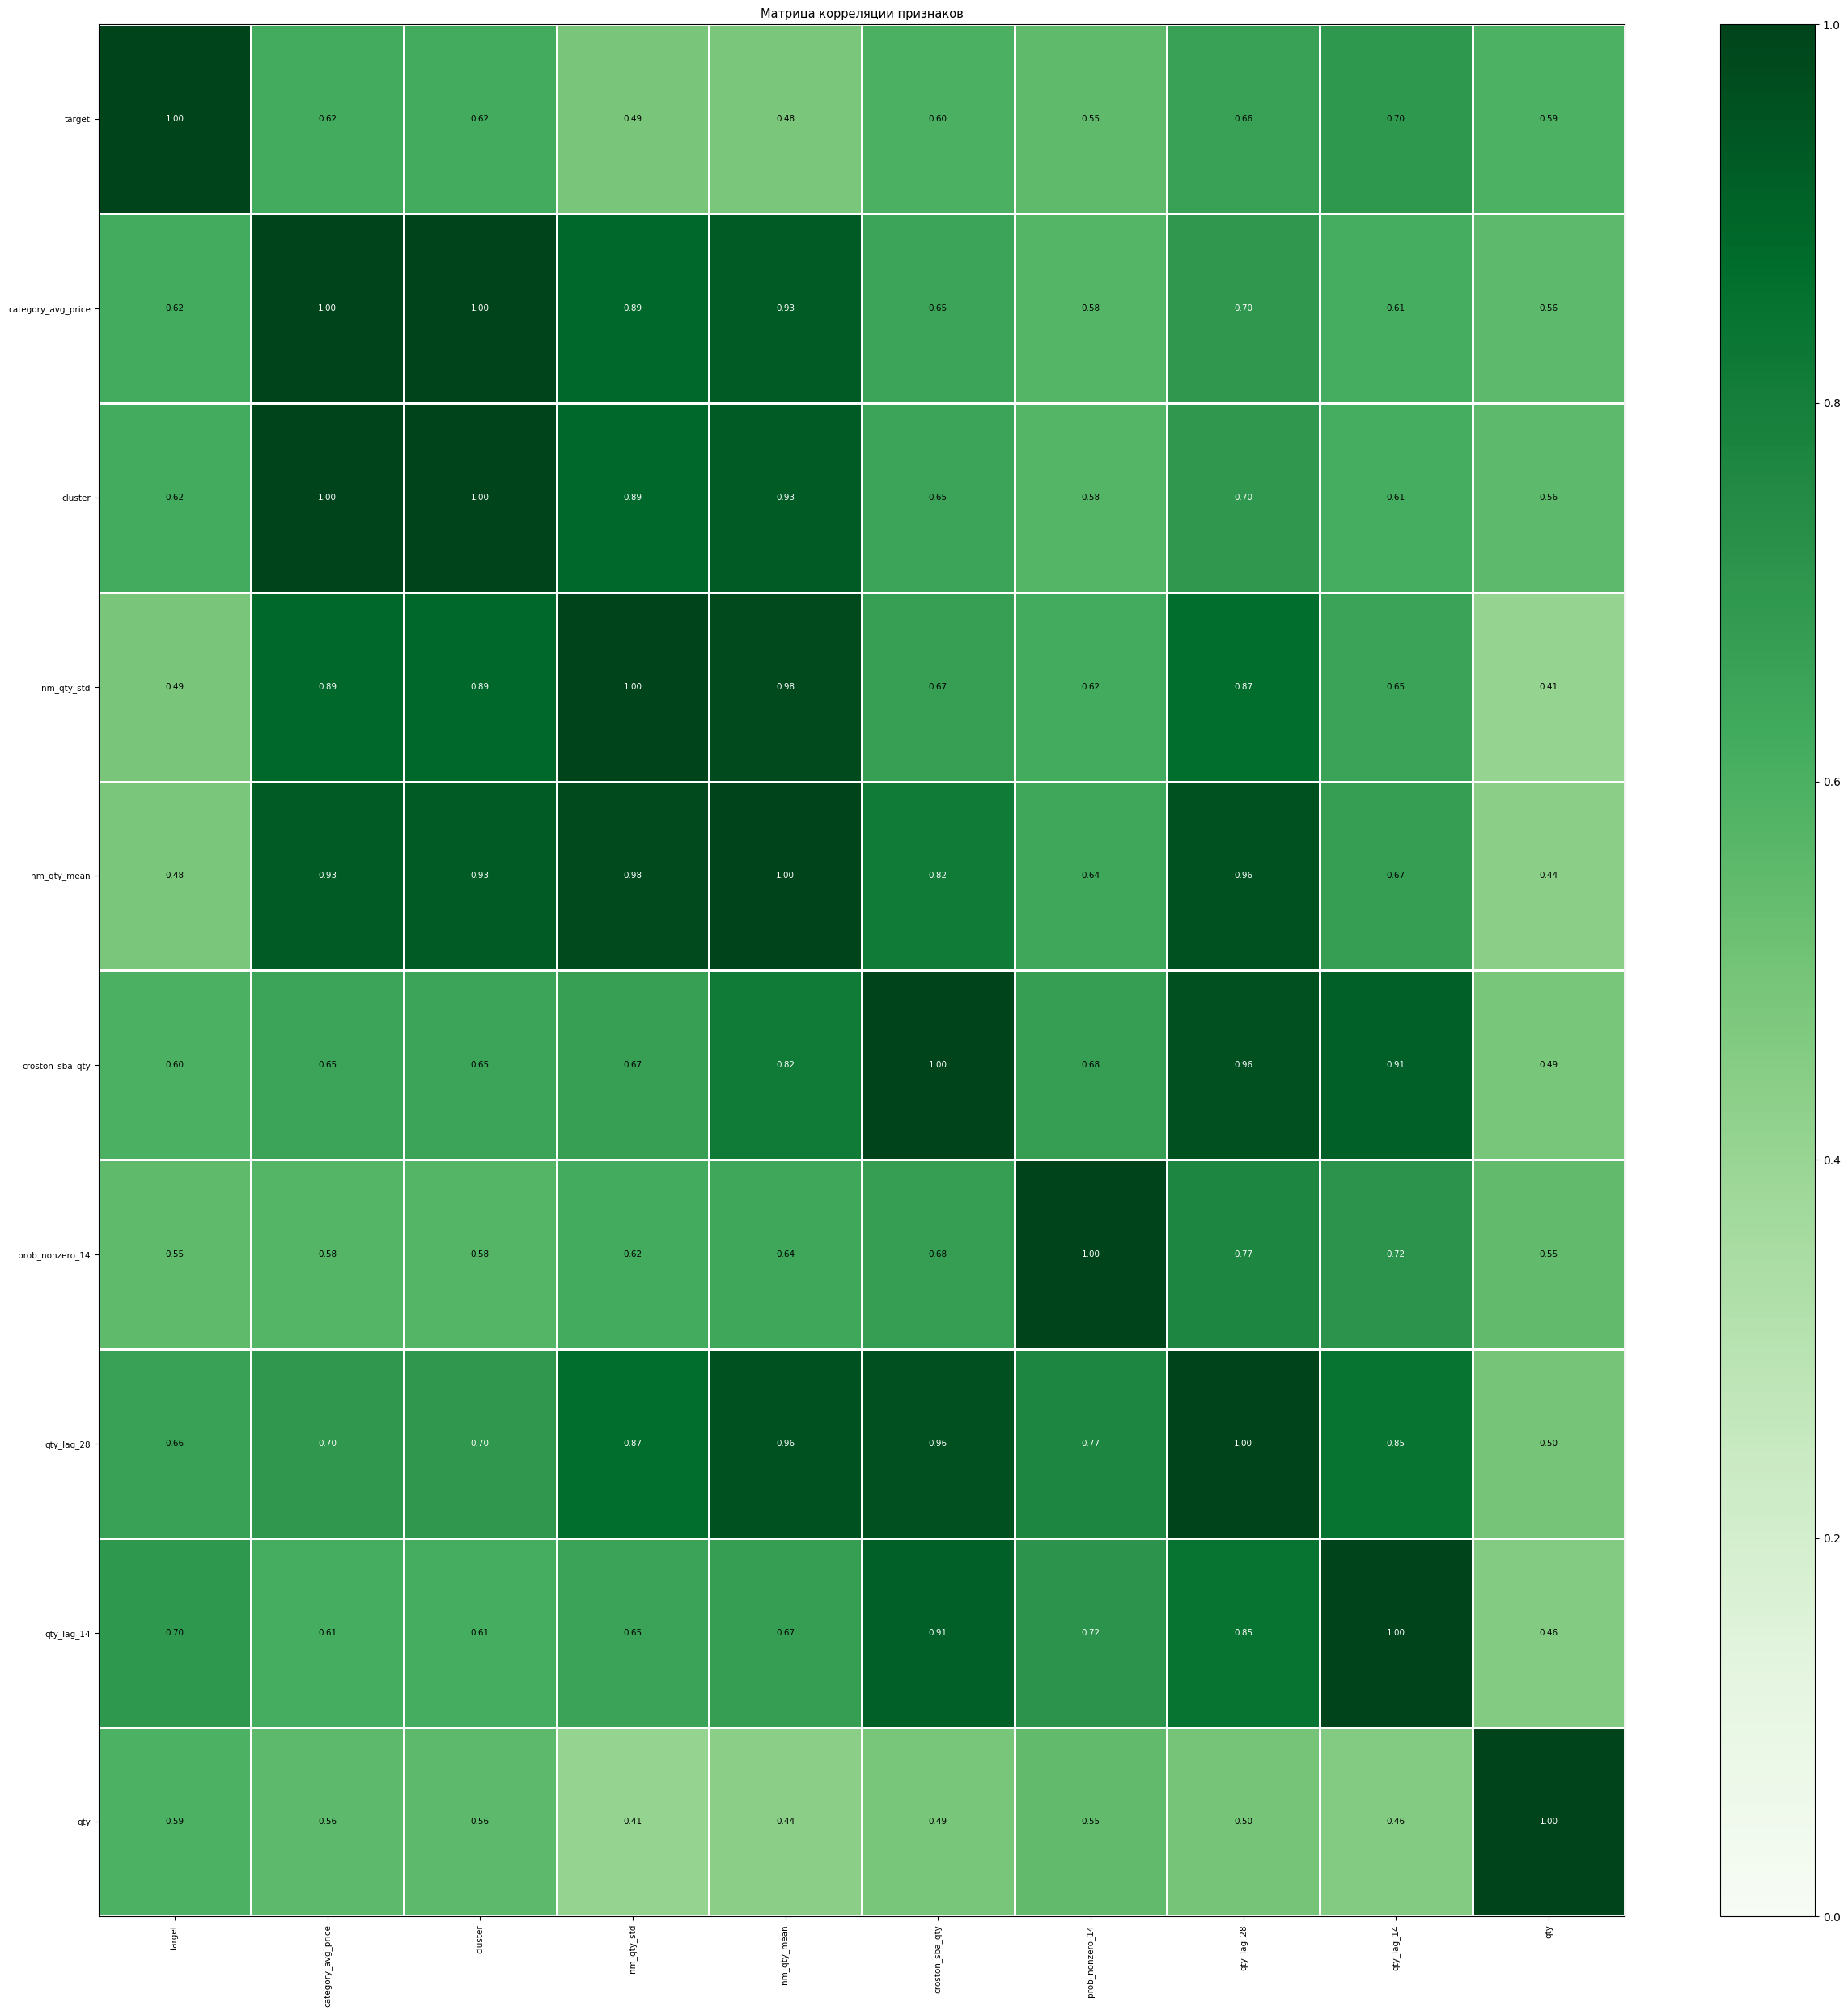

In [ ]:

# Визуализация
plot_correlation_matrix(
    phik_matrix.values,
    x_labels=phik_matrix.columns,
    y_labels=phik_matrix.index,
    vmin=0, vmax=1, color_map='Greens',
    title='Матрица корреляции признаков',
    fontsize_factor=1,
    figsize=(25, 25)
)
plt.tight_layout()
plt.show()

In [8]:
W_POS = 7.0
MULTIPLE = 3.0

RANDOM_STATE = 42
HORIZON_DAYS = 14
MAX_TARGET = 18
# нижняя граница по дате для отборов, можно поменять через переменную окружения

MIN_DATE = pd.Timestamp(os.getenv('MIN_DATE', '2025-05-14'))
warnings.filterwarnings('ignore')



# преобразования целевой переменной

def y_to_model_space(y):
    y = np.asarray(y, dtype=np.float32)
    return np.log1p(y / MULTIPLE).astype(np.float32)

def y_from_model_space(y_hat):
    y_hat = np.asarray(y_hat, dtype=np.float32)
    return np.expm1(y_hat) * MULTIPLE

def round_to_multiple_of_3(y):
    y = np.asarray(y, dtype=np.float32)
    y = np.clip(y, 0, None)
    return (np.round(y / MULTIPLE) * MULTIPLE).astype(np.int64)


In [9]:
# вспомогательные функции и классы для кросс-валидации и подготовки моделей

def make_time_holdout_masks(dt, test_days=14, gap_days=14):
    dt = pd.to_datetime(pd.Series(dt))
    uniq_dates = np.array(sorted(dt.unique()))

    if len(uniq_dates) <= test_days + gap_days:
        raise ValueError('Слишком мало уникальных дат для такого split.')

    val_dates = uniq_dates[-test_days:]
    val_start = val_dates[0]

    if gap_days > 0:
        gap_dates = uniq_dates[-(test_days + gap_days):-test_days]
        split_point = gap_dates[0]
        gap_start = pd.Timestamp(gap_dates[0]).date()
        gap_end = pd.Timestamp(gap_dates[-1]).date()
    else:
        split_point = val_start
        gap_start, gap_end = None, None

    train_mask = dt < split_point
    val_mask = dt.isin(val_dates)

    train_dates = uniq_dates[uniq_dates < split_point]
    split_info = {
        'train_end': str(pd.Timestamp(train_dates[-1]).date()),
        'gap_start': str(gap_start) if gap_start else None,
        'gap_end': str(gap_end) if gap_end else None,
        'val_start': str(pd.Timestamp(val_dates[0]).date()),
        'val_end': str(pd.Timestamp(val_dates[-1]).date()),
    }
    return train_mask.to_numpy(), val_mask.to_numpy(), split_info


class ExpandingDateCV:
    def __init__(self, n_splits=5, val_days=14, gap_days=14, min_train_days=120):
        self.n_splits = n_splits
        self.val_days = val_days
        self.gap_days = gap_days
        self.min_train_days = min_train_days

    def split(self, dt):
        dt = pd.to_datetime(pd.Series(dt))
        uniq_dates = np.array(sorted(dt.unique()))
        total_days = len(uniq_dates)

        need_days = self.min_train_days + self.gap_days + self.n_splits * self.val_days
        if total_days < need_days:
            raise ValueError(
                f'Недостаточно дат: есть {total_days}, нужно >= {need_days} '
                f'(min_train_days={self.min_train_days}, gap={self.gap_days}, '
                f'n_splits={self.n_splits}, val_days={self.val_days}).'
            )

        for fold in range(self.n_splits):
            val_end = total_days - (self.n_splits - 1 - fold) * self.val_days
            val_start = val_end - self.val_days
            train_end = val_start - self.gap_days

            train_dates = uniq_dates[:train_end]
            val_dates = uniq_dates[val_start:val_end]

            tr_idx = np.flatnonzero(dt.isin(train_dates).to_numpy())
            va_idx = np.flatnonzero(dt.isin(val_dates).to_numpy())
            yield tr_idx, va_idx


DEFAULT_FEATURES = good_cols


def make_pipeline(features):
    preprocess = ColumnTransformer(
        transformers=[
            ('num', SimpleImputer(strategy='median'), features),
        ],
        remainder='drop'
    )

    model = LGBMRegressor(
        objective='regression_l1',
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=-1,
        force_col_wise=True
    )

    return Pipeline([
        ('prep', preprocess),
        ('model', model),
    ])


def evaluate_one_config_cv(X, y, dt, base_pipe, splitter, params=None, w_pos=W_POS):
    params = params or {}
    y = np.asarray(y, dtype=float)

    fold_rows = []
    for fold, (tr_idx, va_idx) in enumerate(splitter.split(dt), start=1):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y[tr_idx], y[va_idx]

        sample_weight = np.where(y_tr > 0, w_pos, 1.0)

        model = clone(base_pipe).set_params(**params)
        model.fit(
            X_tr,
            y_to_model_space(y_tr),
            model__sample_weight=sample_weight
        )

        pred_va = model.predict(X_va)
        pred_va = y_from_model_space(pred_va)
        pred_va = round_to_multiple_of_3(pred_va)

        fold_rows.append({
            'fold': fold,
            'mae': mae(y_va, pred_va),
            'wmae': wmae(y_va, pred_va, w_pos=w_pos),
            'smape': smape(y_va, pred_va),
        })

    return pd.DataFrame(fold_rows)


def run_grid_search_cv(X, y, dt, base_pipe, splitter, param_grid, max_configs=None):
    all_params = list(ParameterGrid(param_grid))
    if max_configs is not None:
        all_params = all_params[:max_configs]

    rows = []
    for i, params in enumerate(all_params, start=1):
        fold_df = evaluate_one_config_cv(
            X=X, y=y, dt=dt,
            base_pipe=base_pipe,
            splitter=splitter,
            params=params
        )
        row = {k: v for k, v in params.items()}
        row.update({
            'config_id': i,
            'n_folds': len(fold_df),
            'cv_mae_mean': fold_df['mae'].mean(),
            'cv_wmae_mean': fold_df['wmae'].mean(),
            'cv_smape_mean': fold_df['smape'].mean(),
            'cv_wmae_std': fold_df['wmae'].std(ddof=0),
        })
        rows.append(row)

    return (
        pd.DataFrame(rows)
        .sort_values(['cv_wmae_mean', 'cv_mae_mean', 'cv_smape_mean'])
        .reset_index(drop=True)
    )

In [ ]:
# загрузка подготовленных признаков и обучение моделей

train_clean = pd.read_csv('train_clean.csv')
train_clean['dt'] = pd.to_datetime(train_clean['dt'])
train_clean = train_clean.sort_values(['dt', 'nm_id']).reset_index(drop=True)
train_clean = train_clean[train_clean['dt'] >= MIN_DATE].reset_index(drop=True)

FEATURES = [c for c in train_clean.columns if c not in ['dt', 'nm_id', 'target', 'qty']]

must_have = FEATURES + ['target', 'dt']
missing = [c for c in must_have if c not in train_clean.columns]
if missing:
    raise ValueError(f'В train_clean.csv не хватает колонок: {missing}')

X = train_clean[FEATURES].copy()
y = train_clean['target'].astype(float).to_numpy()
dt = train_clean['dt'].copy()

print('X shape:', X.shape, '| y shape:', y.shape)
print('date min:', dt.min().date(), 'date max:', dt.max().date())

train_mask, test_mask, split_info = make_time_holdout_masks(
    dt, test_days=14, gap_days=0
)
print('Holdout split:', split_info)

X_train_hold, y_train_hold = X.loc[train_mask], y[train_mask]
X_test_hold, y_test_hold = X.loc[test_mask], y[test_mask]

base_pipe = make_pipeline(FEATURES)

cv_splitter = ExpandingDateCV(
    n_splits=1,
    val_days=14,
    gap_days=0,
    min_train_days=21
)

baseline_fold_scores = evaluate_one_config_cv(
    X=X, y=y, dt=dt, base_pipe=base_pipe, splitter=cv_splitter, params={}
)
print('Baseline CV mean:',
      baseline_fold_scores[['mae', 'wmae', 'smape']].mean().to_dict())

lgbm_param_grid = {
    'model__n_estimators': [100, 250],
    'model__max_depth': [32, 64],
    'model__learning_rate': [0.1, 0.05],
    'model__num_leaves': [30, 60, 90],
    'model__min_child_samples': [20, 40, 60],
    'model__subsample': [0.8, 1.0],
    'model__colsample_bytree': [0.8, 1.0],
}

search_results = run_grid_search_cv(
    X=X,
    y=y,
    dt=dt,
    base_pipe=base_pipe,
    splitter=cv_splitter,
    param_grid=lgbm_param_grid,
    max_configs=64
)

display(search_results.head(10))

best_params = {k: search_results.loc[0, k] for k in lgbm_param_grid.keys()}
print('Best params:', best_params)

best_pipe = clone(base_pipe).set_params(**best_params)
sw_train_hold = np.where(y_train_hold > 0, W_POS, 1.0)

best_pipe.fit(
    X_train_hold,
    y_to_model_space(y_train_hold),
    model__sample_weight=sw_train_hold
)

pred_hold = best_pipe.predict(X_test_hold)
pred_hold = y_from_model_space(pred_hold)
pred_hold = round_to_multiple_of_3(pred_hold)

print('Holdout MAE  :', mae(y_test_hold, pred_hold))
print('Holdout wMAE :', wmae(y_test_hold, pred_hold, w_pos=W_POS))
print('Holdout sMAPE:', smape(y_test_hold, pred_hold))

# финальная модель на всей истории

test_clean = pd.read_csv('test_clean.csv')
test_clean['dt'] = pd.to_datetime(test_clean['dt'])

missing_test = [c for c in FEATURES if c not in test_clean.columns]
if missing_test:
    raise ValueError(f'В test_clean.csv не хватает колонок: {missing_test}')

X_test_final = test_clean[FEATURES].copy()

final_pipe = clone(base_pipe).set_params(**best_params)
sw_full = np.where(y > 0, W_POS, 1.0)

final_pipe.fit(
    X,
    y_to_model_space(y),
    model__sample_weight=sw_full
)

test_pred = final_pipe.predict(X_test_final)
test_pred = y_from_model_space(test_pred)
test_pred = round_to_multiple_of_3(test_pred)

submission = pd.DataFrame({
    'nm_id': test_clean['nm_id'],
    'dt': test_clean['dt'].dt.strftime('%Y-%m-%d'),
    'qty': test_pred
})
submission.to_csv('submission_lgbm.csv', index=False)

submission.head()


X shape: (27406, 82) | y shape: (27406,)
date min: 2025-05-14 date max: 2025-06-23
Holdout split: {'train_end': '2025-06-09', 'gap_start': None, 'gap_end': None, 'val_start': '2025-06-10', 'val_end': '2025-06-23'}
Baseline CV mean: {'mae': 1.0693251533742332, 'wmae': 1.9779618889809445, 'smape': 0.4881022096512895}


,model__colsample_bytree,model__learning_rate,model__max_depth,model__min_child_samples,model__n_estimators,model__num_leaves,model__subsample,config_id,n_folds,cv_mae_mean,cv_wmae_mean,cv_smape_mean,cv_wmae_std
0,0.8,0.1,32,40,100,60,0.8,15,1,0.990644,1.875808,0.444073,0.0
1,0.8,0.1,32,40,100,60,1.0,16,1,0.990644,1.875808,0.444073,0.0
2,0.8,0.1,64,40,100,60,0.8,51,1,0.990644,1.875808,0.444073,0.0
3,0.8,0.1,64,40,100,60,1.0,52,1,0.990644,1.875808,0.444073,0.0
4,0.8,0.1,32,60,250,90,0.8,35,1,0.894939,1.876305,0.377108,0.0
5,0.8,0.1,32,60,250,90,1.0,36,1,0.894939,1.876305,0.377108,0.0
6,0.8,0.1,32,40,250,60,0.8,21,1,0.934969,1.890472,0.399282,0.0
7,0.8,0.1,32,40,250,60,1.0,22,1,0.934969,1.890472,0.399282,0.0
8,0.8,0.1,64,40,250,60,0.8,57,1,0.934969,1.890472,0.399282,0.0
9,0.8,0.1,64,40,250,60,1.0,58,1,0.934969,1.890472,0.399282,0.0


Best params: {'model__n_estimators': np.int64(100), 'model__max_depth': np.int64(32), 'model__learning_rate': np.float64(0.1), 'model__num_leaves': np.int64(60), 'model__min_child_samples': np.int64(40), 'model__subsample': np.float64(0.8), 'model__colsample_bytree': np.float64(0.8)}
Holdout MAE  : 0.9906441717791411
Holdout wMAE : 1.875807787903894
Holdout sMAPE: 0.4440731592878832


,nm_id,dt,qty
0,0045b02f-cd56-4d2f-9d03-c5f40f1da697,2025-07-08,0
1,0045b02f-cd56-4d2f-9d03-c5f40f1da697,2025-07-09,0
2,0045b02f-cd56-4d2f-9d03-c5f40f1da697,2025-07-10,3
3,0045b02f-cd56-4d2f-9d03-c5f40f1da697,2025-07-11,3
4,0045b02f-cd56-4d2f-9d03-c5f40f1da697,2025-07-12,3
